# Image Colorization

1. Adopt the implementation of the U-Net network from the previous task and train it on the task of image colorization.
2. Remove the skip connections of the implemented U-Net network, retrain it on the colorization task and examine the difference.

In [5]:
import torchvision
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
import glob
import cv2
import numpy as np

import torch
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class UNetBlock(nn.Module):
    """Basic UNet block consisting of two convolutional layers with batch norm and ReLU."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
            
    def forward(self, x):
        return self.block(x)



class UNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # Encoder
        self.encoder_stage1 = UNetBlock(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.encoder_stage2 = UNetBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.encoder_stage3 = UNetBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.encoder_stage4 = UNetBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(512, 1024)

        # Decoder
        self.up_transpose4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.decoder_stage4 = UNetBlock(1024, 512)

        self.up_transpose3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder_stage3 = UNetBlock(512, 256)

        self.up_transpose2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder_stage2 = UNetBlock(256, 128)

        self.up_transpose1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder_stage1 = UNetBlock(128, 64)

        # Final output layer
        self.output_layer = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.encoder_stage1(x)
        # print("enc1:", enc1.shape)
        enc2 = self.encoder_stage2(self.pool1(enc1))
        enc3 = self.encoder_stage3(self.pool2(enc2))
        enc4 = self.encoder_stage4(self.pool3(enc3))
        # print("enc4:", enc4.shape)

        bottleneck = self.bottleneck(self.pool4(enc4))
        # print("bottleneck:", bottleneck.shape)

        # Decoder
        dec4 = self.decoder_stage4(torch.cat([enc4, self.up_transpose4(bottleneck)], dim=1))
        dec3 = self.decoder_stage3(torch.cat([enc3, self.up_transpose3(dec4)], dim=1))
        dec2 = self.decoder_stage2(torch.cat([enc2, self.up_transpose2(dec3)], dim=1))
        dec1 = self.decoder_stage1(torch.cat([enc1, self.up_transpose1(dec2)], dim=1))
        # print("dec1:", dec1.shape)

        out = self.output_layer(dec1)
        # print("out:", out.shape)

        return out


## Download the dataset from google drive:

In [3]:
!gdown  --id 1gS35-TyG0EEcTGes-WtglcVl2Ij4WGT0
# use the other file id if the first one doesn't work
#!gdown  --id 1Q0UIc27o6qlFAqNiDKfM06KwpzHCGKLU
!unzip -q landscapes.zip -d ./data

/var/home/enei/Boxes/jupyter/.venv/lib64/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1gS35-TyG0EEcTGes-WtglcVl2Ij4WGT0
From (redirected): https://drive.google.com/uc?id=1gS35-TyG0EEcTGes-WtglcVl2Ij4WGT0&confirm=t&uuid=d0b14fa6-82c2-4cfa-b412-dc04791d56ab
To: /var/home/enei/Boxes/jupyter/landscapes.zip
100%|████████████████████████████████████████| 650M/650M [00:11<00:00, 57.8MB/s]


## Colorization dataset

The dataset class loads the image and also converts them to a grayscale version. The image pair is then used for training.

In [7]:
from torch.utils.data import Dataset, DataLoader
import glob
import cv2
import numpy as np

class ColorizationDataset(Dataset):

    def __init__(self, train=True):
        self.all_images = sorted(glob.glob("./data/*"))
        self.images = self.all_images[:-500]
        self.test_images = self.all_images[-500:]
        if not train:
          self.images = self.test_images

        self.resize_shape = (256, 256)

    def __len__(self):
        return len(self.images)

    def transform_image(self, image_path):
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)

        channels=3
        image = cv2.resize(image, dsize=(self.resize_shape[1], self.resize_shape[0]))
        gray_image = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
        image = np.array(image).reshape((image.shape[0], image.shape[1], channels)).astype(np.float32) / 255.0
        gray_image = np.array(gray_image).reshape((image.shape[0], image.shape[1], 1)).astype(np.float32) / 255.0

        image = np.transpose(image, (2, 0, 1))
        gray_image = np.transpose(gray_image, (2, 0, 1))
        return image, gray_image

    def __getitem__(self, idx):
        image, gray_image = self.transform_image(self.images[idx])
        sample = {'image': image, "gray_image": gray_image, 'idx': idx}

        return sample

## Examples of the training image pairs

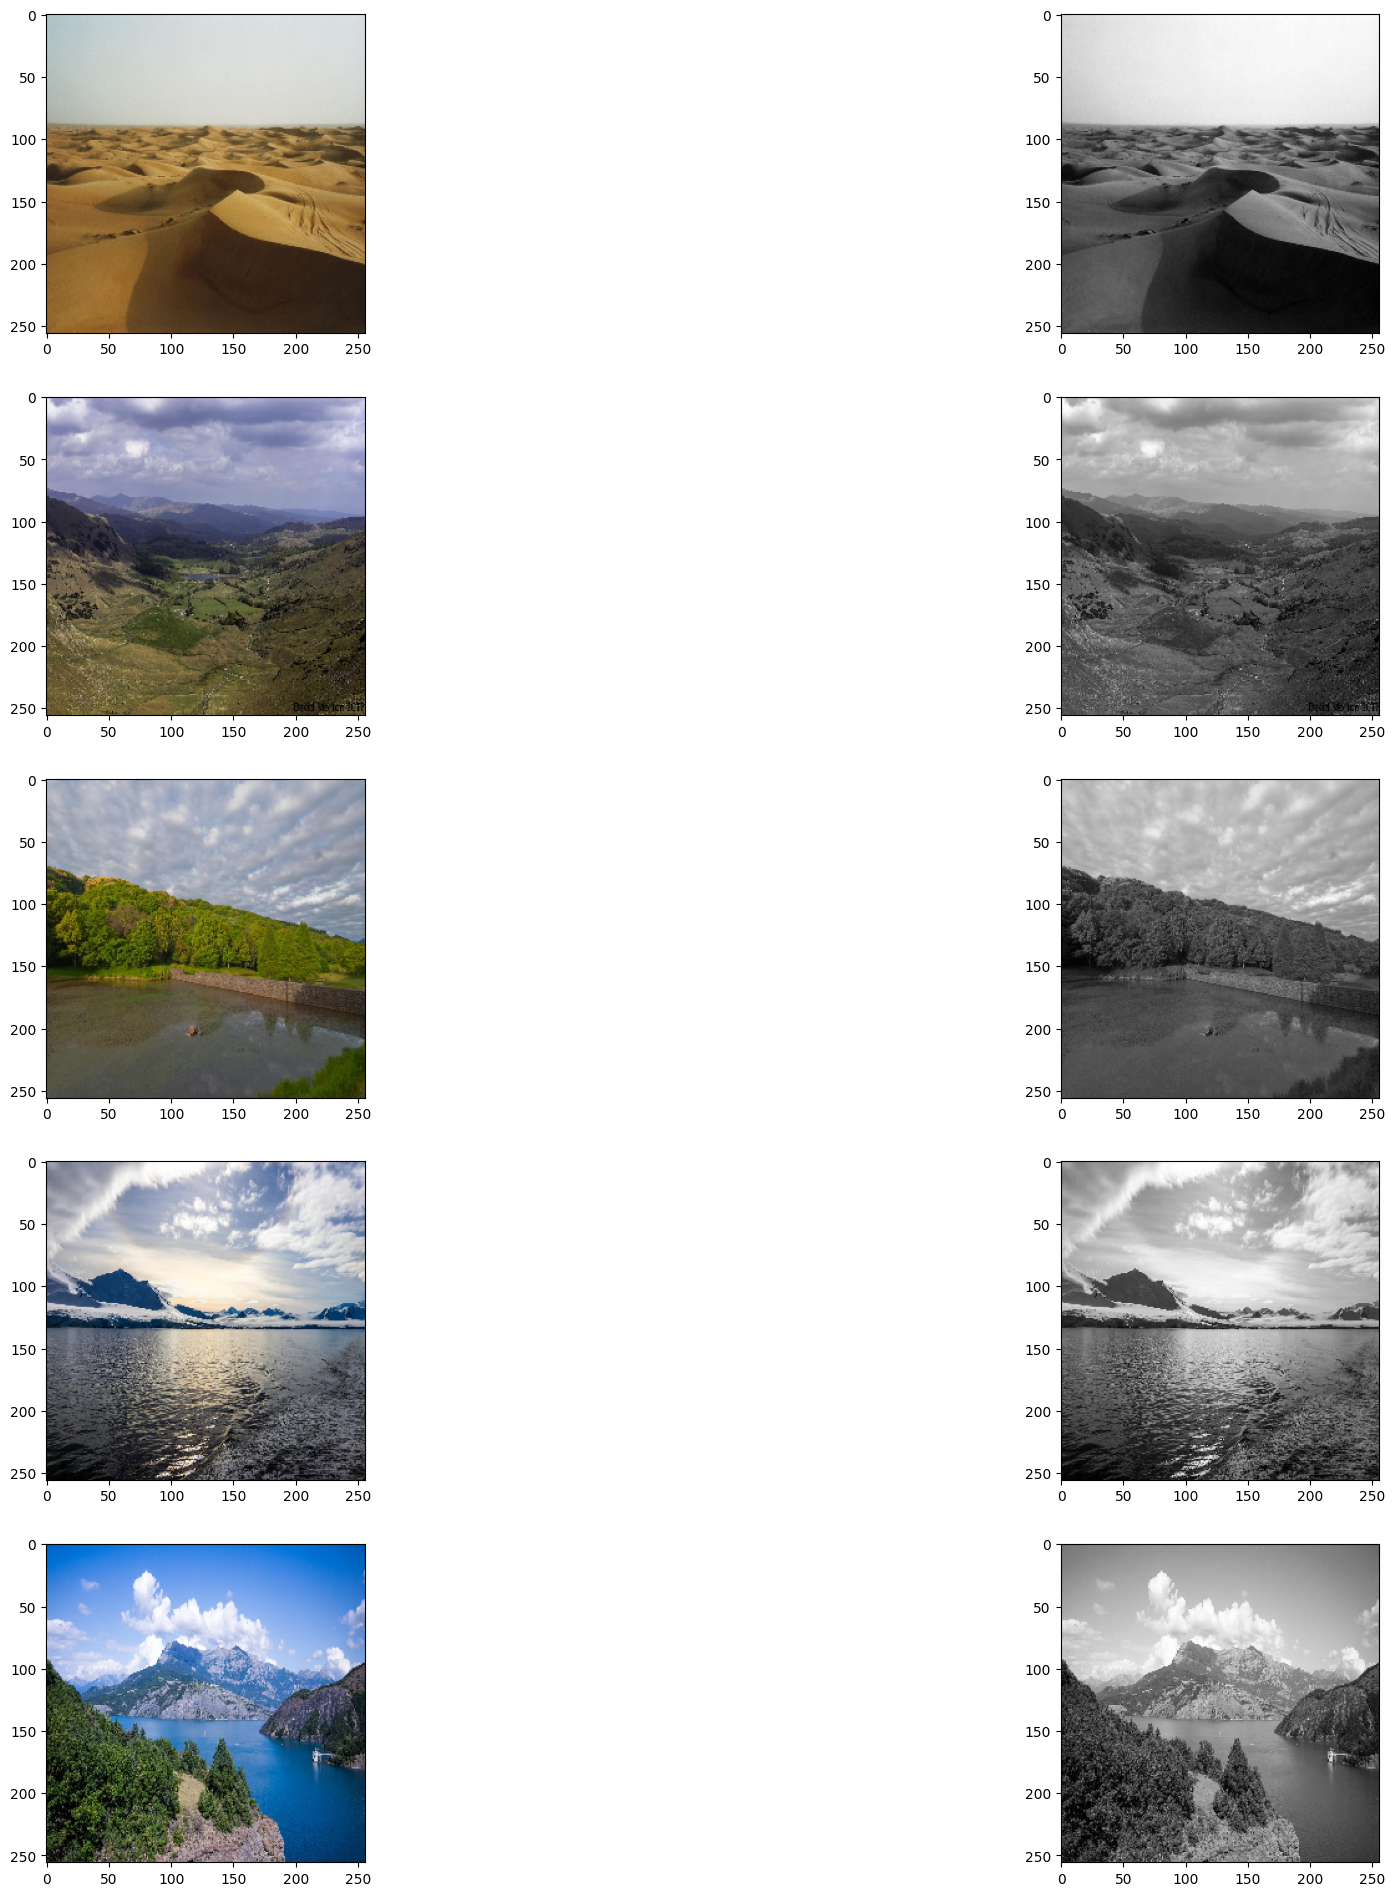

In [8]:
import matplotlib.pyplot as plt
trainset = ColorizationDataset(train=True)
fig=plt.figure(figsize=(24, 24))
columns = 2
rows = 5
for i in range(rows):
  batch = trainset[np.random.randint(len(trainset))]
  img = batch['image'].transpose((1,2,0))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  gray = batch['gray_image'][0,:,:]
  fig.add_subplot(rows, columns, i*columns+1)
  plt.imshow(img)
  fig.add_subplot(rows, columns, i*columns+2)
  plt.imshow(gray,cmap='gray')
plt.show()


## Training loop


In [10]:
import torch
from tqdm.notebook import tqdm


trainset = ColorizationDataset(train=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = ColorizationDataset(train=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)


import torch.optim as optim

net = UNet()
net.cuda()
optimizer = optim.Adam(net.parameters(), lr=0.0005)

epochs=5
for epoch in range(epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    with tqdm(total=len(trainset), desc ='Epoch: '+str(epoch)+"/"+str(epochs), unit='img') as prog_bar:
      for i, data in enumerate(trainloader, 0):
          # get the inputs;
          gray_images = data["gray_image"]
          color_images = data["image"]

          # Get the inputs to the GPU
          gray_images = gray_images.cuda()
          color_images = color_images.cuda()

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          outputs = net(gray_images)
          loss = nn.functional.l1_loss(outputs, color_images)
          loss.backward()
          optimizer.step()

          prog_bar.set_postfix(**{'loss': loss.data.cpu().detach().numpy()})
          prog_bar.update(4)


Epoch: 0/5:   0%|          | 0/3819 [00:00<?, ?img/s]

Epoch: 1/5:   0%|          | 0/3819 [00:00<?, ?img/s]

KeyboardInterrupt: 

## Display output examples from the test set

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94407815..1.0833627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1867933..1.1683875].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6226343..1.0793817].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2472082..1.573097].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09849194..1.0812291].


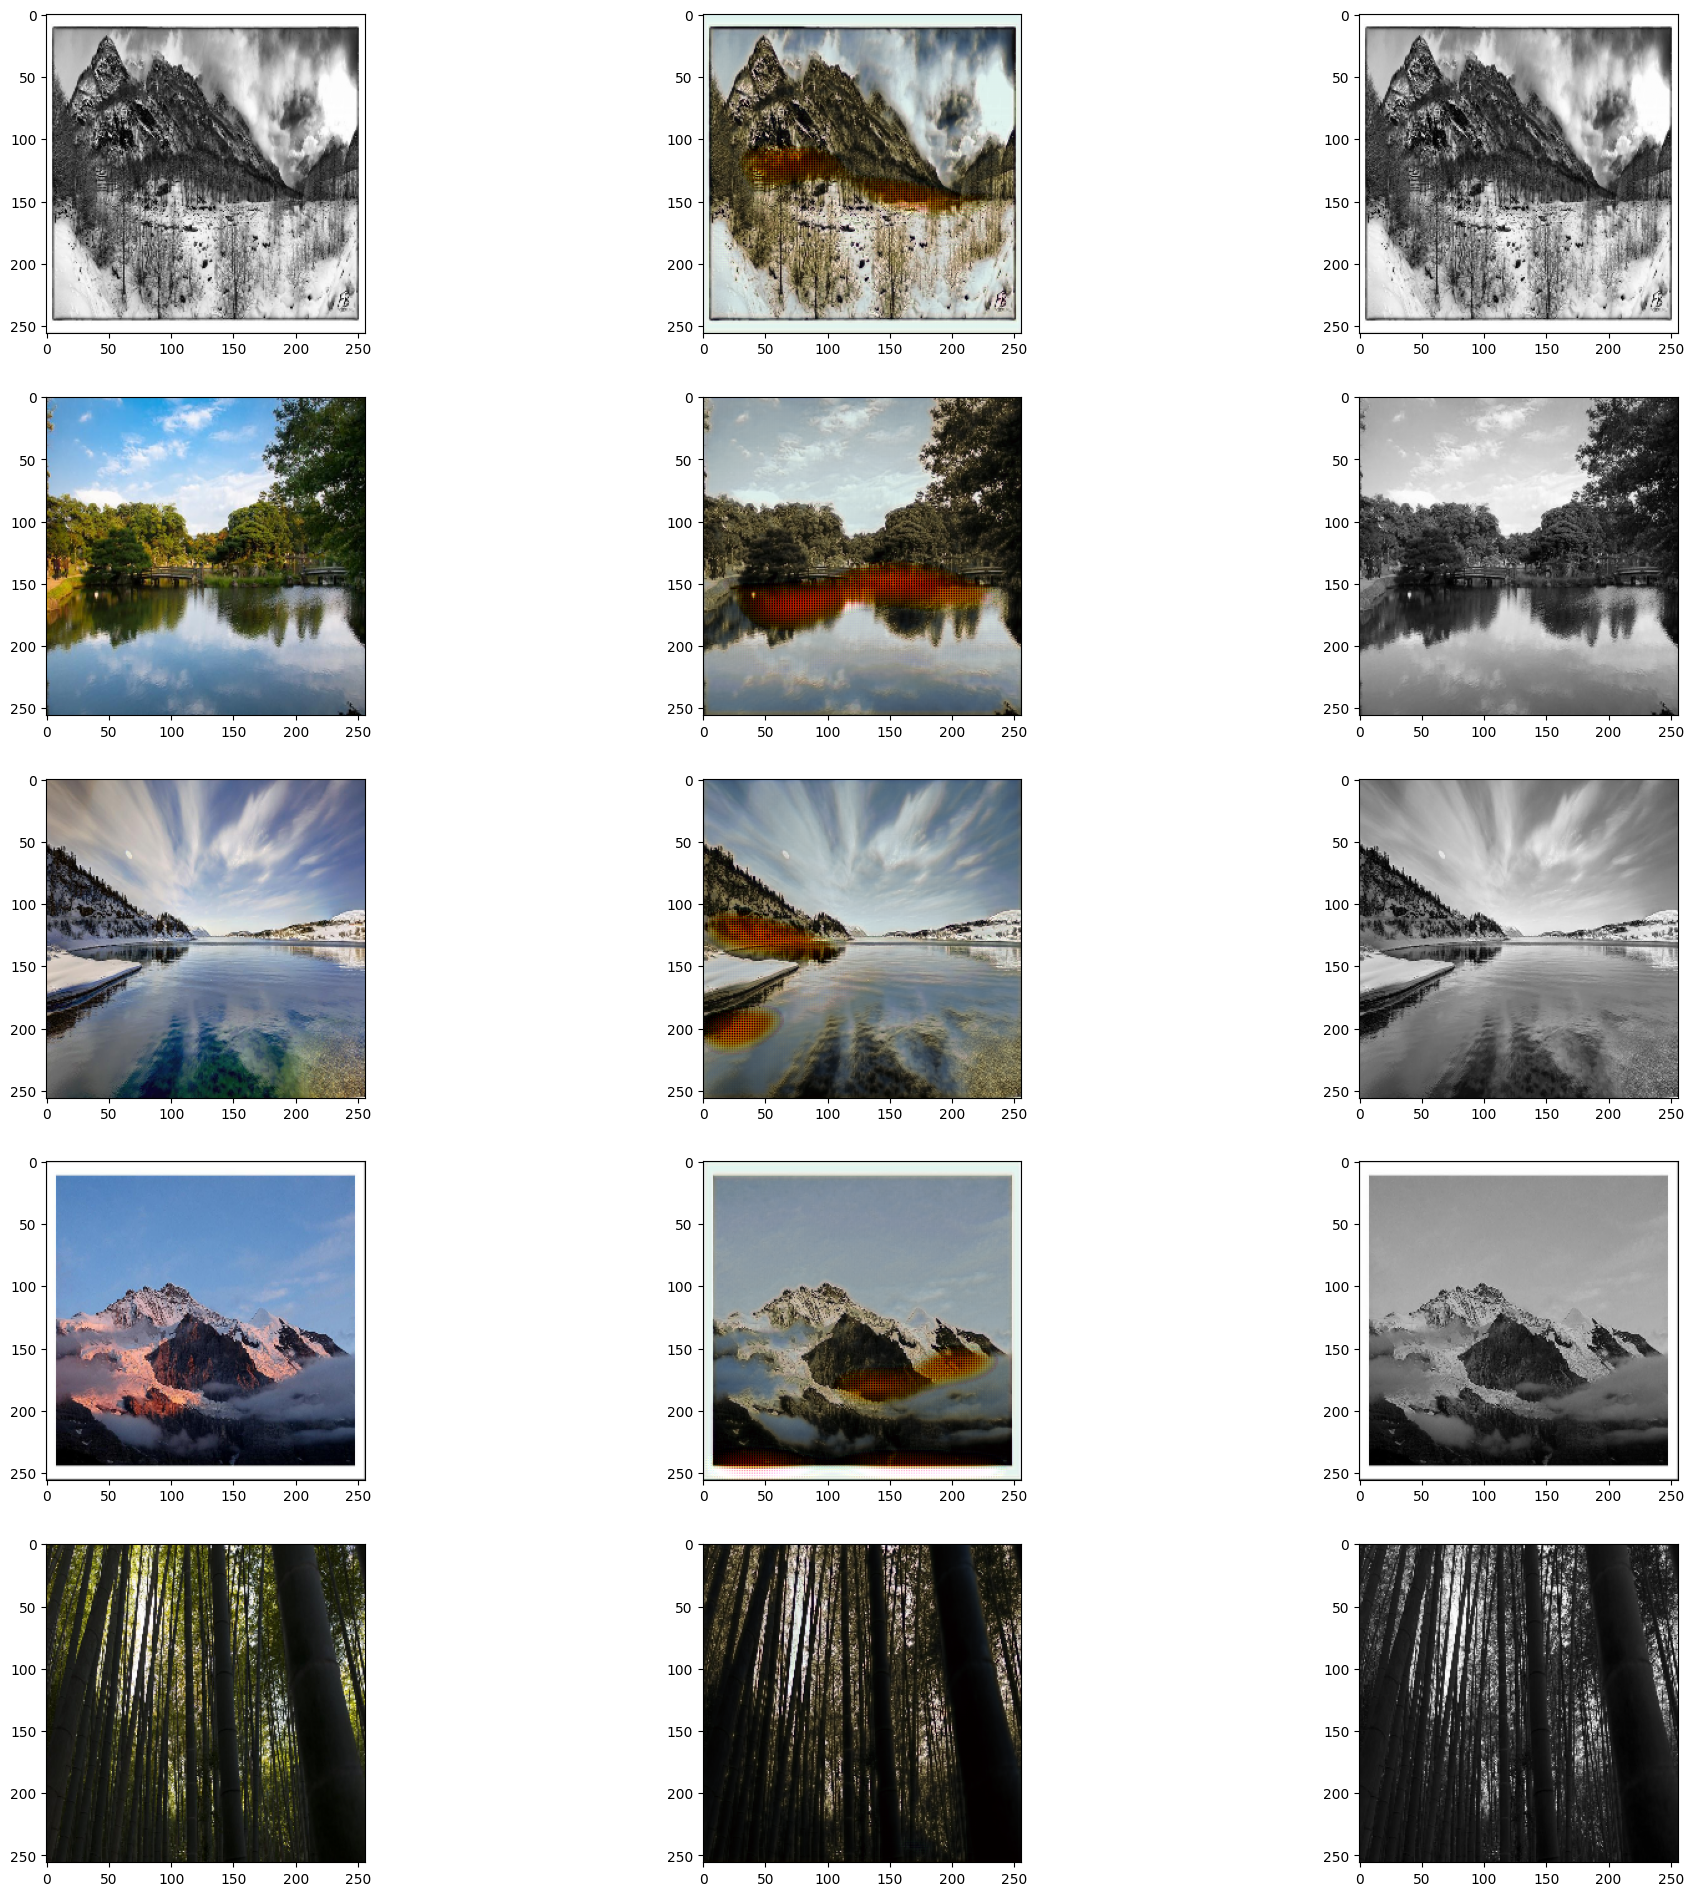

In [11]:
net.eval()
fig=plt.figure(figsize=(24, 24))
columns = 3
rows = 5
for i in range(rows):
  batch = testset[i+80]
  img = batch['image']
  gray = batch['gray_image']
  img_tensor = torch.from_numpy(gray).cuda()
  img_tensor = img_tensor.unsqueeze(0)
  outputs = net(img_tensor)
  out_image = outputs[0,:,:,:].detach().cpu().numpy().transpose((1,2,0))
  out_image = cv2.cvtColor(out_image,cv2.COLOR_BGR2RGB)

  img=img.transpose((1,2,0))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  gray = gray[0,:,:]
  fig.add_subplot(rows, columns, i*columns+1)
  plt.imshow(img)
  fig.add_subplot(rows, columns, i*columns+2)
  plt.imshow(out_image)
  fig.add_subplot(rows, columns, i*columns+3)
  plt.imshow(gray,cmap='gray')

plt.show()

In [ ]:
class SkiplessUNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # Encoder
        self.encoder_stage1 = UNetBlock(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.encoder_stage2 = UNetBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.encoder_stage3 = UNetBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.encoder_stage4 = UNetBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = UNetBlock(512, 1024)

        # Decoder (no skip connections)
        self.up_transpose4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.decoder_stage4 = UNetBlock(512, 512)

        self.up_transpose3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder_stage3 = UNetBlock(256, 256)

        self.up_transpose2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder_stage2 = UNetBlock(128, 128)

        self.up_transpose1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder_stage1 = UNetBlock(64, 64)

        # Final output layer
        self.output_layer = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x = self.encoder_stage1(x)
        x = self.encoder_stage2(self.pool1(x))
        x = self.encoder_stage3(self.pool2(x))
        x = self.encoder_stage4(self.pool3(x))
        x = self.bottleneck(self.pool4(x))

        # Decoder (skip connections removed)
        x = self.decoder_stage4(self.up_transpose4(x))
        x = self.decoder_stage3(self.up_transpose3(x))
        x = self.decoder_stage2(self.up_transpose2(x))
        x = self.decoder_stage1(self.up_transpose1(x))

        return self.output_layer(x)
    

In [ ]:


net = SkiplessUNet()
net.cuda()
optimizer = optim.Adam(net.parameters(), lr=0.0001)


epochs=5
for epoch in range(epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    with tqdm(total=len(trainset), desc ='Epoch: '+str(epoch)+"/"+str(epochs), unit='img') as prog_bar:
      for i, data in enumerate(trainloader, 0):
          # get the inputs;
          gray_images = data["gray_image"]
          color_images = data["image"]

          # Get the inputs to the GPU
          gray_images = gray_images.cuda()
          color_images = color_images.cuda()

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          outputs = net(gray_images)
          loss = nn.functional.l1_loss(outputs, color_images)
          loss.backward()
          optimizer.step()

          prog_bar.set_postfix(**{'loss': loss.data.cpu().detach().numpy()})
          prog_bar.update(4)

Epoch: 0/5:   0%|          | 0/3820 [00:00<?, ?img/s]

Epoch: 1/5:   0%|          | 0/3820 [00:00<?, ?img/s]

Epoch: 2/5:   0%|          | 0/3820 [00:00<?, ?img/s]

Epoch: 3/5:   0%|          | 0/3820 [00:00<?, ?img/s]

Epoch: 4/5:   0%|          | 0/3820 [00:00<?, ?img/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


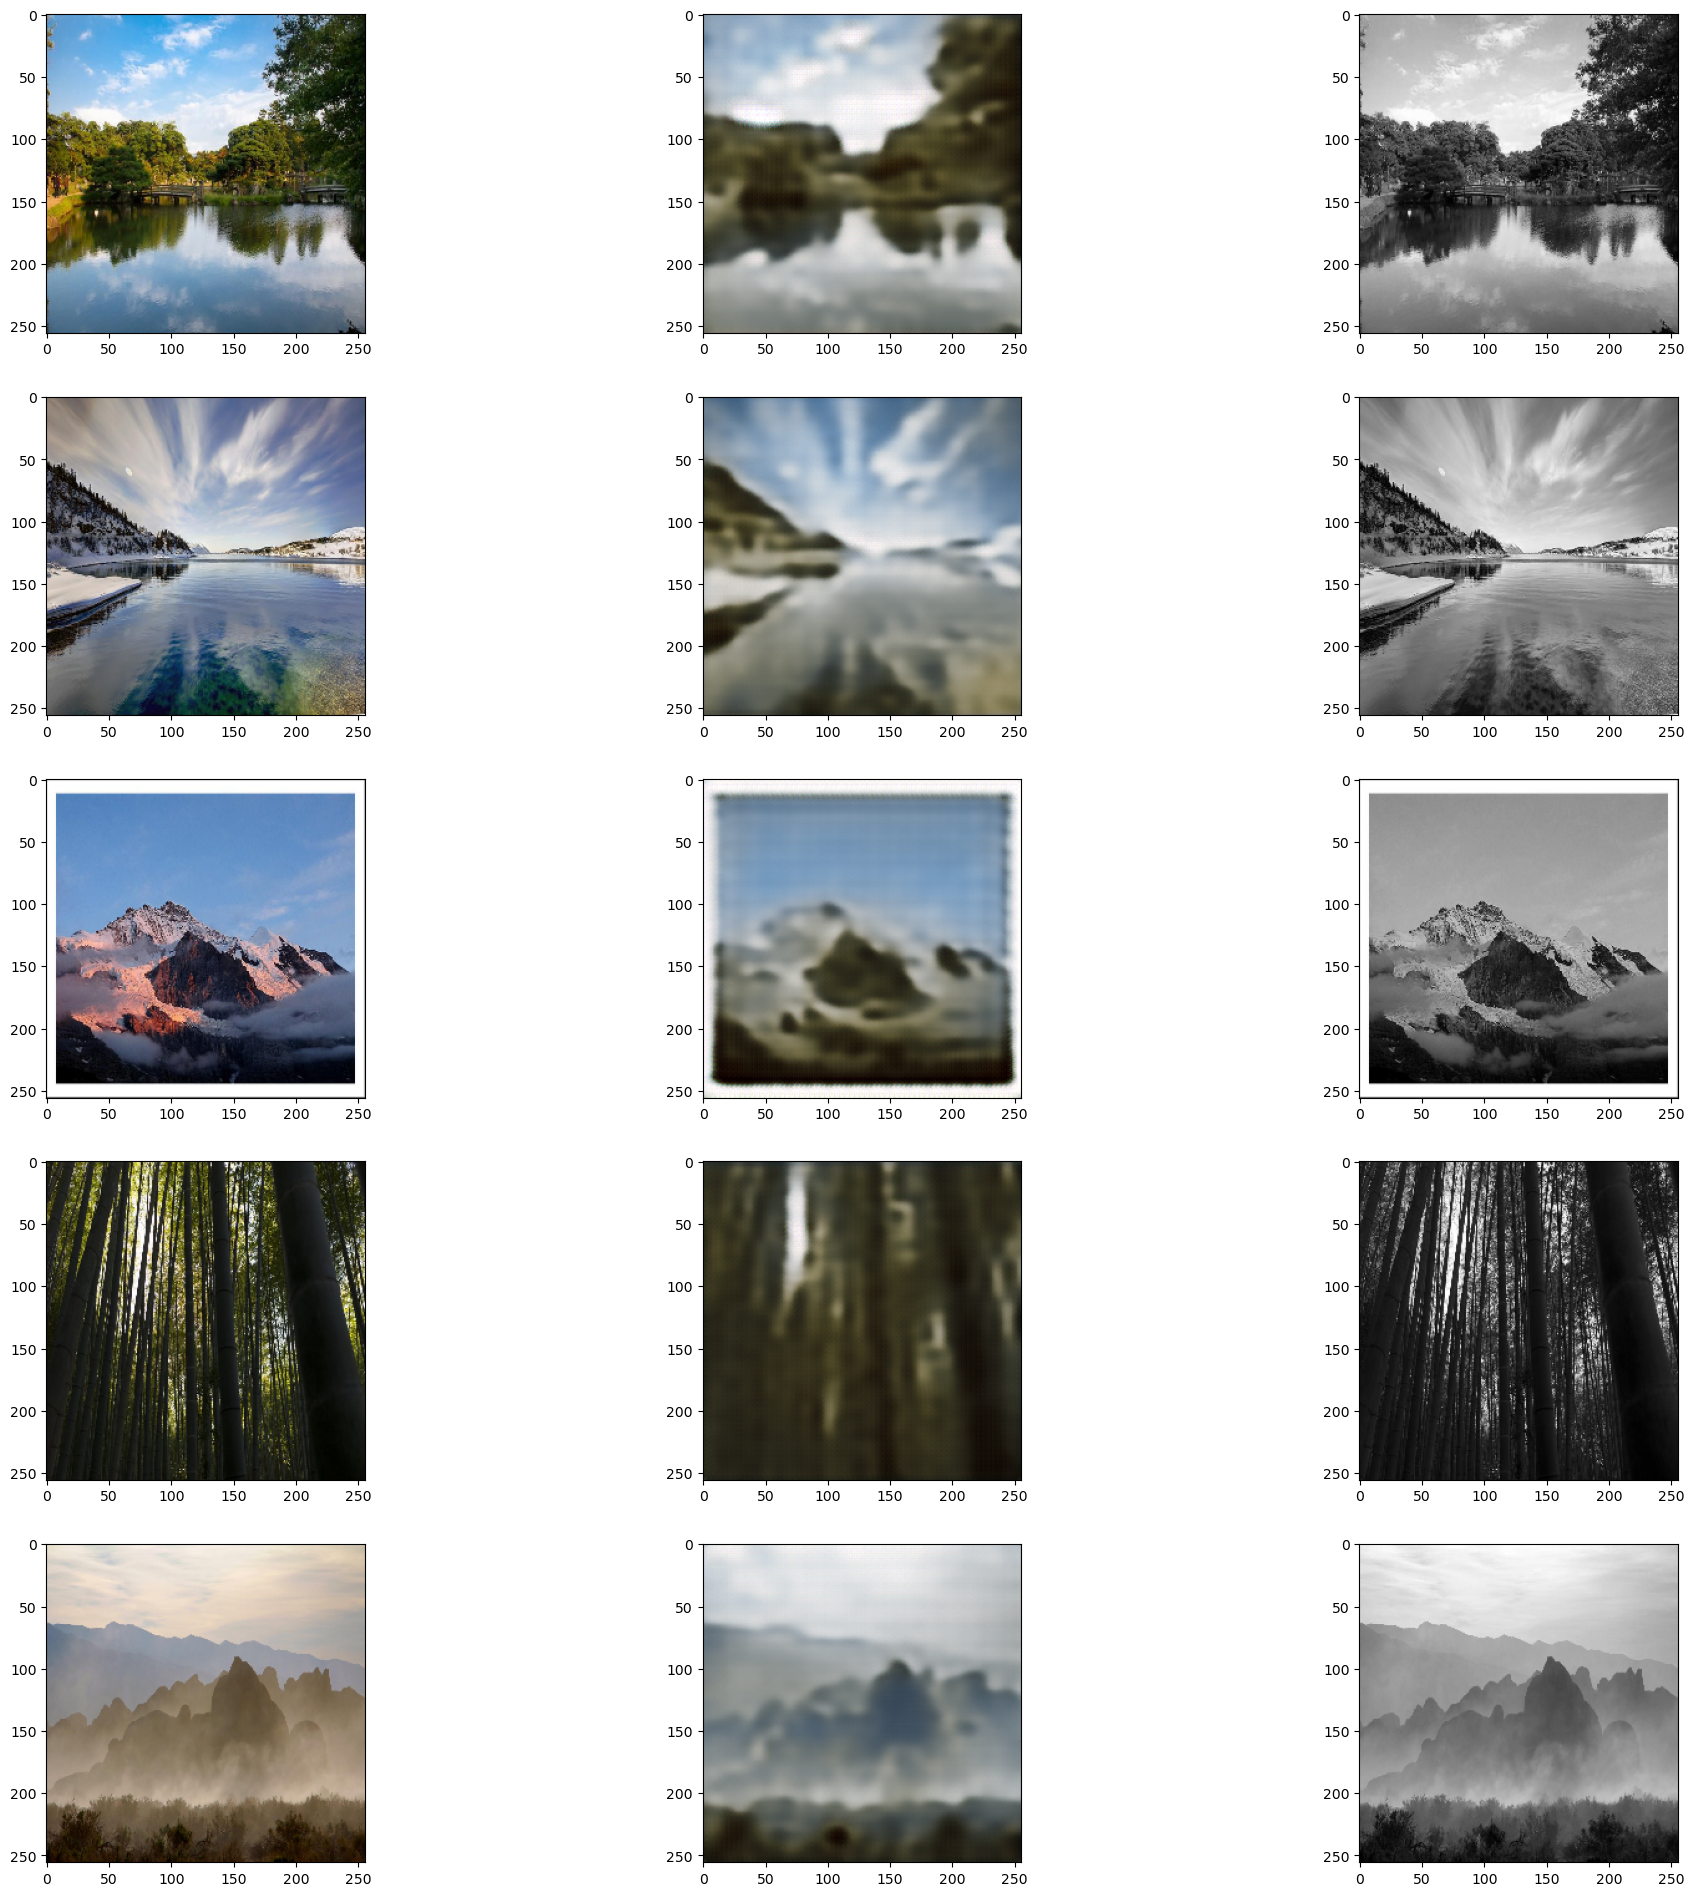

In [10]:
net.eval()
fig=plt.figure(figsize=(24, 24))
columns = 3
rows = 5
for i in range(rows):
  batch = testset[i+80]
  img = batch['image']
  gray = batch['gray_image']
  img_tensor = torch.from_numpy(gray).cuda()
  img_tensor = img_tensor.unsqueeze(0)
  outputs = net(img_tensor)
  out_image = outputs[0,:,:,:].detach().cpu().numpy().transpose((1,2,0))
  out_image = cv2.cvtColor(out_image,cv2.COLOR_BGR2RGB)

  img=img.transpose((1,2,0))
  img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  gray = gray[0,:,:]
  fig.add_subplot(rows, columns, i*columns+1)
  plt.imshow(img)
  fig.add_subplot(rows, columns, i*columns+2)
  plt.imshow(out_image)
  fig.add_subplot(rows, columns, i*columns+3)
  plt.imshow(gray,cmap='gray')

plt.show()